# Part 1d - Finfing pupil - projections and finding center

## Setup

In [1]:
import os
import random
import re

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import cv2
from PIL import Image

## Functions

In [2]:
# Loading and preview ------------------------------------------------

def load_images_ending_with_pattern(folder_path, regex):
    images = []
    pattern = re.compile(regex)

    for root, _, files in os.walk(folder_path):
        for file in files:
            if not pattern.match(file):
                continue
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()
                image = cv2.imread(file_path, cv2.IMREAD_COLOR)
                if image is not None:
                    images.append(image)
            except Exception:
                print(f"Skipping non-image file: {file_path}")
    return images

def preview_images(images, num_previews=5):
    if not images:
        print("No images to display.")
        return

    num_previews = min(num_previews, len(images))
    selected_images = images[:num_previews]
    
    cols = min(15, num_previews)
    rows = math.ceil(num_previews / 15)
    
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, img in enumerate(selected_images):
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Resizing -----------------------------------------------------------

def resize_images(images, max_size=256):
    resized = []
    for img in images:
        h, w = img.shape[:2]
        scale = max_size / max(h, w)
        new_size = (int(w * scale), int(h * scale))  # (width, height)
        resized_img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
        resized.append(resized_img)
    return resized

# Greyscale ----------------------------------------------------------

def convert_images_to_greyscale(images):
    grey_images = []
    for img in images:
        if len(img.shape) == 3:
            grey_img = np.mean(img, axis=2).astype(img.dtype)
        else:
            grey_img = img.copy()
        grey_images.append(grey_img)
    return grey_images

# Binarization -------------------------------------------------------

def adaptive_binarize_pupil(
    grey_images,
    initial_factor,
    white_ratio_thresh=0.9,
    min_factor=1.0,
    factor_step=0.5,
    verbose=False
):
    pupil_binaries = []

    for idx, grey in enumerate(grey_images):
        X = initial_factor
        while True:

            #------------------------------------------
            # Image sizes
            h, w = grey.shape
            # Treshold based on mean
            P = np.sum(grey) / (h * w)
            # Modified treshold
            P = P / X
            # Binarization
            bin_image = np.zeros_like(grey, dtype=np.uint8)
            bin_image[grey >= P] = 255
            #------------------------------------------

            white_ratio = np.mean(bin_image == 255)
            if white_ratio > white_ratio_thresh and (X - factor_step) >= min_factor:
                new_X = round(X - factor_step, 2)
                if verbose:
                    print(
                        f"Image {idx}: white ratio {white_ratio:.3f} > {white_ratio_thresh}, "
                        f"lowering factor {X:.2f} → {new_X:.2f} and retrying"
                    )
                X = new_X
                continue
            break

        # Print final threshold if not verbose
        if not verbose:
            print(
                f"Image {idx}: final threshold P/X = {P/X:.2f} (factor X = {X:.2f}), "
                f"white ratio = {white_ratio:.3f}"
            )

        pupil_binaries.append(bin_image)

    return pupil_binaries

# Morphologial operations --------------------------------------------

def get_structuring_element(shape, ksize, anchor=None):
    rows, cols = ksize
    if anchor is None:
        anchor = (rows // 2, cols // 2)
    if shape.lower() == "rect":
        kernel = np.ones((rows, cols), dtype=np.uint8)
    elif shape.lower() == "ellipse":
        kernel = np.zeros((rows, cols), dtype=np.uint8)
        # Use the center of the kernel for ellipse definition.
        cy, cx = rows // 2, cols // 2  
        a = rows / 2.0
        b = cols / 2.0
        for i in range(rows):
            for j in range(cols):
                # Equation of ellipse centered at (cy, cx)
                if ((i - cy) / a)**2 + ((j - cx) / b)**2 <= 1:
                    kernel[i, j] = 1
    elif shape.lower() == "cross":
        kernel = np.zeros((rows, cols), dtype=np.uint8)
        # Place ones in the row and column corresponding to anchor
        ay, ax = anchor
        if 0 <= ay < rows:
            kernel[ay, :] = 1
        if 0 <= ax < cols:
            kernel[:, ax] = 1
    else:
        raise ValueError("Unsupported kernel shape. Choose 'rect', 'ellipse', or 'cross'.")
    return kernel, anchor

def erosion(image, kernel, anchor):
    krows, kcols = kernel.shape
    ay, ax = anchor
    pad_top = ay
    pad_bottom = krows - ay - 1
    pad_left = ax
    pad_right = kcols - ax - 1
    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=image.min())
    out = np.zeros_like(image)
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+krows, j:j+kcols]
            out[i, j] = np.max(region[kernel==1])
    return out

def dilation(image, kernel, anchor):
    krows, kcols = kernel.shape
    ay, ax = anchor
    pad_top = ay
    pad_bottom = krows - ay - 1
    pad_left = ax
    pad_right = kcols - ax - 1
    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=image.max())
    out = np.zeros_like(image)
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+krows, j:j+kcols]
            out[i, j] = np.min(region[kernel==1])
    return out

def opening(image, kernel, anchor):
    eroded = erosion(image, kernel, anchor)
    opened = dilation(eroded, kernel, anchor)
    return opened

def closing(image, kernel, anchor):
    dilated = dilation(image, kernel, anchor)
    closed = erosion(dilated, kernel, anchor)
    return closed

# Remove artifacts away from center ----------------------------------

def mask_outside_boundary(images, x_thresh=0.9, y_thresh=0.9):
    masked = []
    for img in images:
        h, w = img.shape[:2]
        cx, cy = w/2.0, h/2.0
        dx, dy = x_thresh*(w/2.0), y_thresh*(h/2.0)
        left, right   = cx - dx, cx + dx
        top, bottom   = cy - dy, cy + dy

        # Create a boolean mask of pixels to white‑out:
        ys, xs = np.ogrid[:h, :w]
        outside = (xs < left) | (xs > right) | (ys < top) | (ys > bottom)

        out = img.copy()
        if img.ndim == 2:
            out[outside] = 255
        else:
            out[outside] = (255, 255, 255)
        masked.append(out)
    return masked

### Load images and preprocessing

Image 0: final threshold P/X = 5.66 (factor X = 5.70), white ratio = 0.975
Image 1: final threshold P/X = 6.27 (factor X = 5.30), white ratio = 0.974
Image 2: final threshold P/X = 3.79 (factor X = 6.35), white ratio = 0.974
Image 3: final threshold P/X = 3.80 (factor X = 6.60), white ratio = 0.969
Image 4: final threshold P/X = 7.93 (factor X = 4.55), white ratio = 0.975
Image 5: final threshold P/X = 6.20 (factor X = 5.20), white ratio = 0.975
Image 6: final threshold P/X = 3.59 (factor X = 7.00), white ratio = 0.975
Image 7: final threshold P/X = 3.09 (factor X = 7.15), white ratio = 0.975
Image 8: final threshold P/X = 7.74 (factor X = 4.40), white ratio = 0.975
Image 9: final threshold P/X = 6.92 (factor X = 4.65), white ratio = 0.974
Image 10: final threshold P/X = 4.96 (factor X = 6.05), white ratio = 0.975
Image 11: final threshold P/X = 7.44 (factor X = 5.00), white ratio = 0.975
Image 12: final threshold P/X = 15.77 (factor X = 3.15), white ratio = 0.973
Image 13: final thres

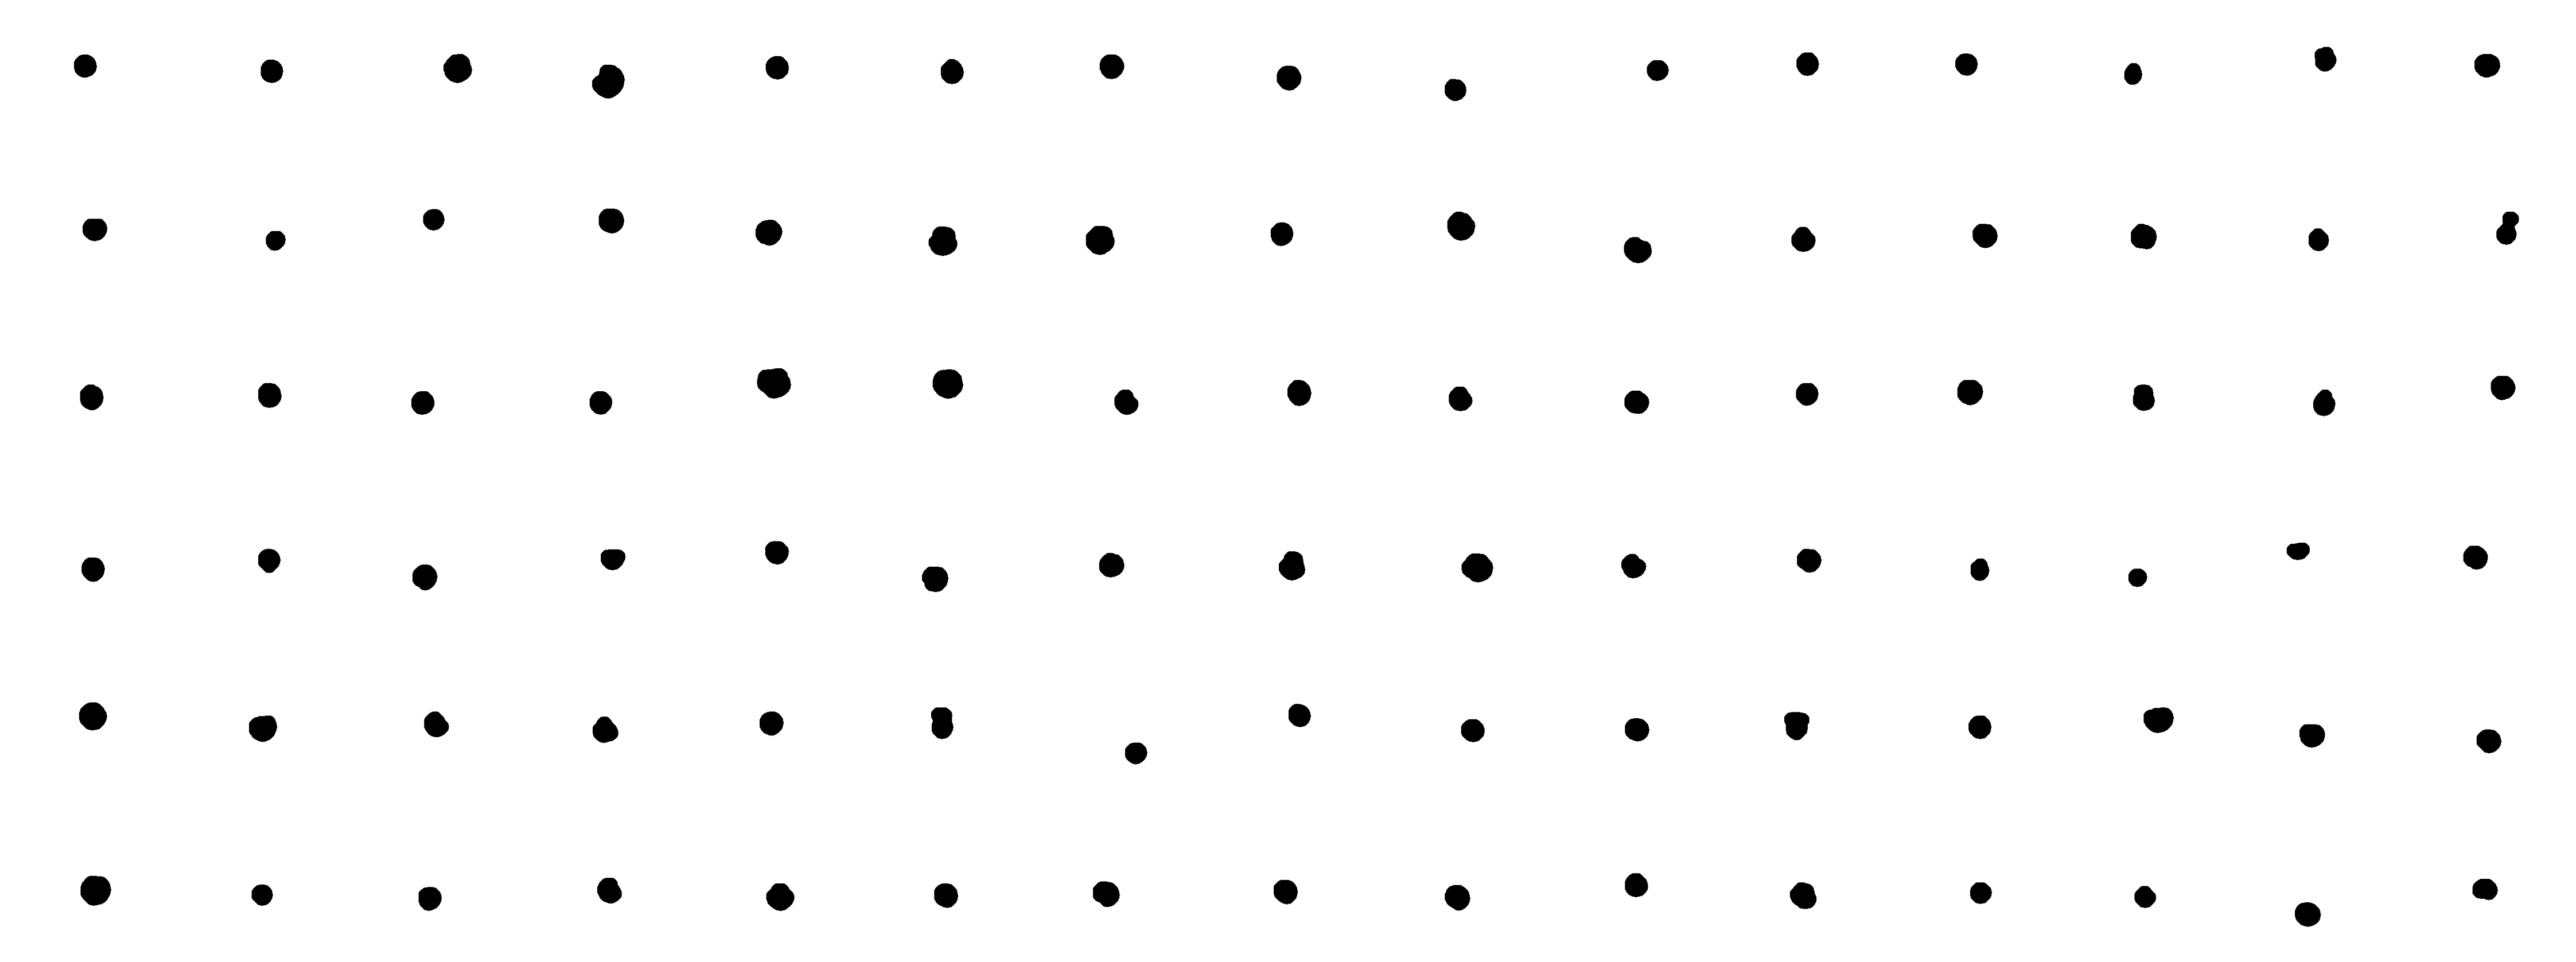

In [4]:
# Loading
images = load_images_ending_with_pattern('MMU-Iris-Database', r'.*[^0-9]?1\.[a-zA-Z]+$')

# Greyscale
grey_images = convert_images_to_greyscale(images)

# Binarization
binarized_pupil_images = adaptive_binarize_pupil(
        grey_images,
        initial_factor=15,
        white_ratio_thresh=0.975,
        min_factor=1.0,
        factor_step=0.05,
        verbose=False
)

# Closing
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (5.5/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
closed_pupil_images = [closing(img, structuring_element, anchor) for img in binarized_pupil_images]

# Opening
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (10/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
opened_pupil_images = [opening(img, structuring_element, anchor) for img in closed_pupil_images]

# Removing artifacts near border
cleaned_pupil_images = mask_outside_boundary(opened_pupil_images, x_thresh=0.75, y_thresh=0.75)

preview_images(cleaned_pupil_images, num_previews=len(cleaned_pupil_images))

## Projections

In [28]:
# For computing ------------------------------

def compute_projections(image):
    h, w = image.shape
    # horizontal & vertical
    h_proj = np.sum(image == 0, axis=1)
    v_proj = np.sum(image == 0, axis=0)

    # main diagonal offsets d = j - i
    d_off = np.arange(-h+1, w)
    d_proj = np.array([
        sum(image[i, i + d] == 0
            for i in range(max(0, -d), min(h, w - d)))
        for d in d_off
    ])

    # anti-diagonal offsets s = i + j
    ad_off = np.arange(0, h + w - 1)
    ad_proj = np.array([
        sum(image[i, s - i] == 0
            for i in range(max(0, s - (w - 1)), min(h, s + 1)))
        for s in ad_off
    ])

    return h_proj, v_proj, d_proj, ad_proj, d_off, ad_off

def get_pupil_centers_from_projections(pupil_projections):
    centers = []

    for (h_proj, v_proj, d_proj, ad_proj, d_off, ad_off) in pupil_projections:
        h = h_proj.shape[0]
        w = v_proj.shape[0]

        # 1) indices of max in each projection
        h_maxs  = np.flatnonzero(h_proj  == h_proj.max())   # y‑coords
        v_maxs  = np.flatnonzero(v_proj  == v_proj.max())   # x‑coords
        d_idxs  = np.flatnonzero(d_proj  == d_proj.max())
        ad_idxs = np.flatnonzero(ad_proj == ad_proj.max())
        d_maxs  = d_off[d_idxs]    # j - i = d
        ad_maxs = ad_off[ad_idxs]  # i + j = s

        pts = []
        # H and V
        for y in h_maxs:
            for x in v_maxs:
                pts.append((x, y))

        # H and D:  j = i + d  → x = y + d
        for y in h_maxs:
            for d in d_maxs:
                pts.append((y + d, y))

        # H and A:  i + j = s → x = s - y
        for y in h_maxs:
            for s in ad_maxs:
                pts.append((s - y, y))

        # V and D:  x = x, y = x - d
        for x in v_maxs:
            for d in d_maxs:
                pts.append((x, x - d))

        # V and A:  x = x, y = s - x
        for x in v_maxs:
            for s in ad_maxs:
                pts.append((x, s - x))

        # D and A:  j = i + d  and  i + j = s
        # -> i = (s - d)/2,  j = i + d
        for d in d_maxs:
            for s in ad_maxs:
                i = (s - d) / 2.0
                j = i + d
                pts.append((j, i))

        # filter to valid image coords
        valid = [(x, y) for x, y in pts if 0 <= x < w and 0 <= y < h]
        if not valid:
            centers.append((None, None))
        else:
            xs, ys = zip(*valid)
            centers.append((float(np.mean(xs)), float(np.mean(ys))))

    return centers

# For showcase -------------------------------

def show_projection(image):
    h, w = image.shape
    h_proj, v_proj, d_proj, ad_proj, d_off, ad_off = compute_projections(image)

    # Find maxima
    y_max    = np.argmax(h_proj)
    x_max    = np.argmax(v_proj)
    d        = d_off[np.argmax(d_proj)]
    s        = ad_off[np.argmax(ad_proj)]

    # Compute all intersections:
    pts = []
    # H ∩ V
    pts.append((x_max, y_max))
    # H ∩ D: y = y_max, x = y_max + d
    pts.append((y_max + d, y_max))
    # H ∩ A: y = y_max, x = s - y_max
    pts.append((s - y_max, y_max))
    # V ∩ D: x = x_max, y = x_max - d
    pts.append((x_max, x_max - d))
    # V ∩ A: x = x_max, y = s - x_max
    pts.append((x_max, s - x_max))
    # D ∩ A: solve x = y + d and x + y = s => y = (s - d)/2
    y_da = (s - d) / 2
    x_da = y_da + d
    pts.append((x_da, y_da))

    # average
    cx = np.mean([p[0] for p in pts])
    cy = np.mean([p[1] for p in pts])

    # --- plotting ---
    fig = plt.figure(constrained_layout=True, figsize=(10,10))
    gs = fig.add_gridspec(4,2, width_ratios=[4,1], height_ratios=[1,4,1,1])

    ax_vbar   = fig.add_subplot(gs[0,0])
    ax_img    = fig.add_subplot(gs[1,0])
    ax_hbar   = fig.add_subplot(gs[1,1])
    ax_diag   = fig.add_subplot(gs[2,0])
    ax_adiag  = fig.add_subplot(gs[3,0])

    # Vertical projection
    ax_vbar.bar(np.arange(w), v_proj, width=1, color='gray')
    ax_vbar.set_xlim(-0.5, w-0.5)
    ax_vbar.set_ylabel('Count'); ax_vbar.set_xlabel('Column')

    # Image
    ax_img.imshow(image, cmap='gray', extent=[-0.5, w-0.5, h-0.5, -0.5])
    ax_img.add_patch(patches.Rectangle((-0.5,-0.5), w, h, fill=False, edgecolor='red'))
    ax_img.axis('off')

    # Horizontal projection
    ax_hbar.barh(np.arange(h), h_proj, height=1, color='gray')
    ax_hbar.set_ylim(h-0.5, -0.5)
    ax_hbar.set_xlabel('Count'); ax_hbar.set_ylabel('Row')

    # Overlay lines
    ax_img.axhline(y=y_max, color='blue',   ls='--')
    ax_img.axvline(x=x_max, color='green',  ls='--')
    # main diag
    i0, j0 = max(0, -d), max(0, -d) + d
    i1, j1 = min(h-1, w-1-d), min(h-1, w-1-d) + d
    ax_img.plot([j0, j1], [i0, i1], color='orange', ls='--')
    # anti-diag
    i0, j0 = max(0, s-(w-1)), s - max(0, s-(w-1))
    i1, j1 = min(h-1, s),       s - min(h-1, s)
    ax_img.plot([j0, j1], [i0, i1], color='purple', ls='--')

    # red center point
    ax_img.plot(cx, cy, 'ro', markersize=6)

    # Diagonal bar
    ax_diag.bar(d_off, d_proj, width=1, color='gray')
    ax_diag.set_xlim(d_off[0]-0.5, d_off[-1]+0.5)
    ax_diag.set_xlabel('Diagonal offset'); ax_diag.set_ylabel('Count')

    # Anti-diagonal bar
    ax_adiag.bar(ad_off, ad_proj, width=1, color='gray')
    ax_adiag.set_xlim(ad_off[0]-0.5, ad_off[-1]+0.5)
    ax_adiag.set_xlabel('Antidiagonal offset'); ax_adiag.set_ylabel('Count')

    plt.show()

def show_images_with_centers(images, centers, num_previews=None):
    n = len(images)
    if n == 0:
        print("No images to display.")
        return

    if num_previews is None or num_previews > n:
        num_previews = n

    # pick a random subset
    picks = random.sample(list(zip(images, centers)), num_previews)

    cols = min(5, num_previews)
    rows = math.ceil(num_previews / cols)

    plt.figure(figsize=(cols * 2, rows * 2))
    for i, (img, (cx, cy)) in enumerate(picks):
        # prepare for display
        if img.ndim == 3:
            disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            cmap = None
        else:
            disp = img
            cmap = 'gray'

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(disp, cmap=cmap, extent=[0, img.shape[1], img.shape[0], 0])
        ax.axis('off')

        # plot center
        if cx is not None and cy is not None:
            ax.plot(cx, cy, 'ro', markersize=6)

    plt.tight_layout()
    plt.show()

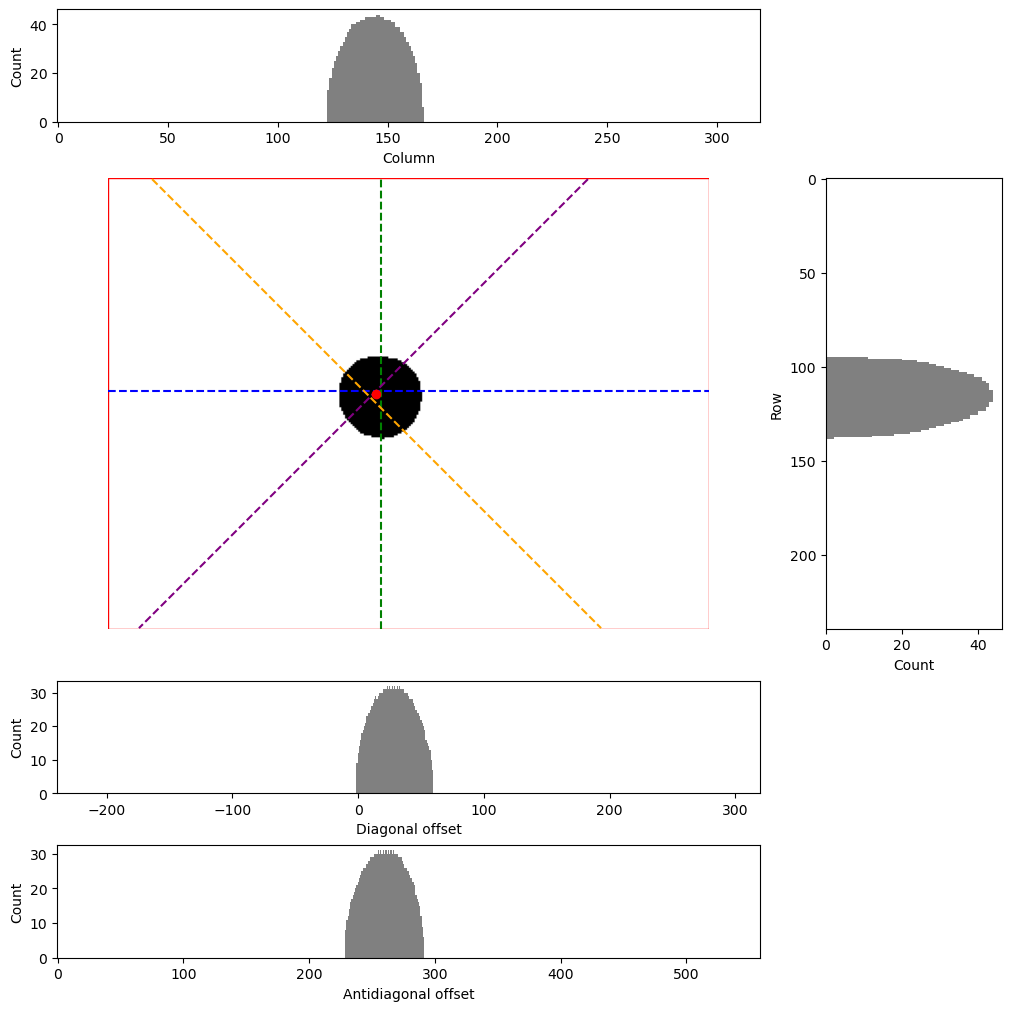

In [29]:
show_projection(random.choice(cleaned_pupil_images))

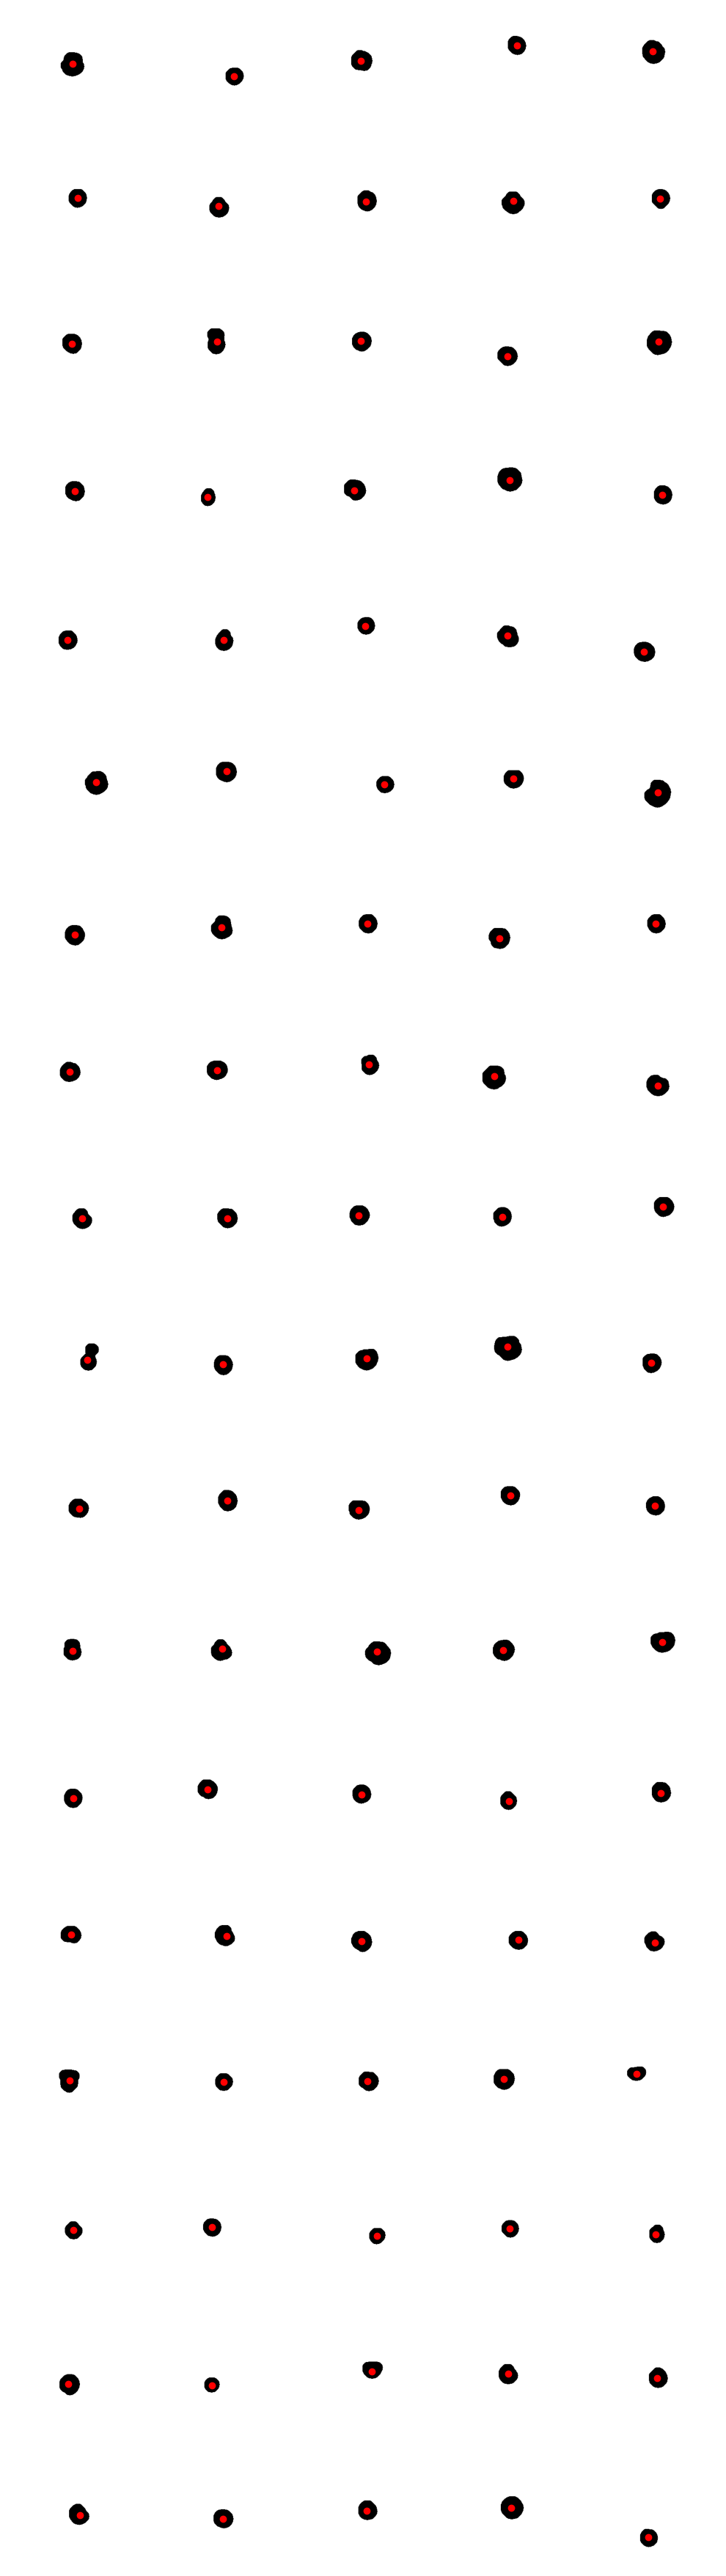

In [30]:
pupil_projections = [compute_projections(img) for img in cleaned_pupil_images]
pupil_centers = get_pupil_centers_from_projections(pupil_projections)

show_images_with_centers(cleaned_pupil_images, pupil_centers, num_previews=len(cleaned_pupil_images))

## Carry over the center do different image

In [33]:
def map_center_to_different_image(center, small_shape, orig_shape):
    cy_small, cx_small = center[1], center[0]
    h_small, w_small = small_shape
    h_orig,  w_orig  = orig_shape

    # scale factors
    scale_x = w_orig / w_small
    scale_y = h_orig / h_small

    # map and round
    cx_orig = int(round(cx_small * scale_x))
    cy_orig = int(round(cy_small * scale_y))
    return (cx_orig, cy_orig)

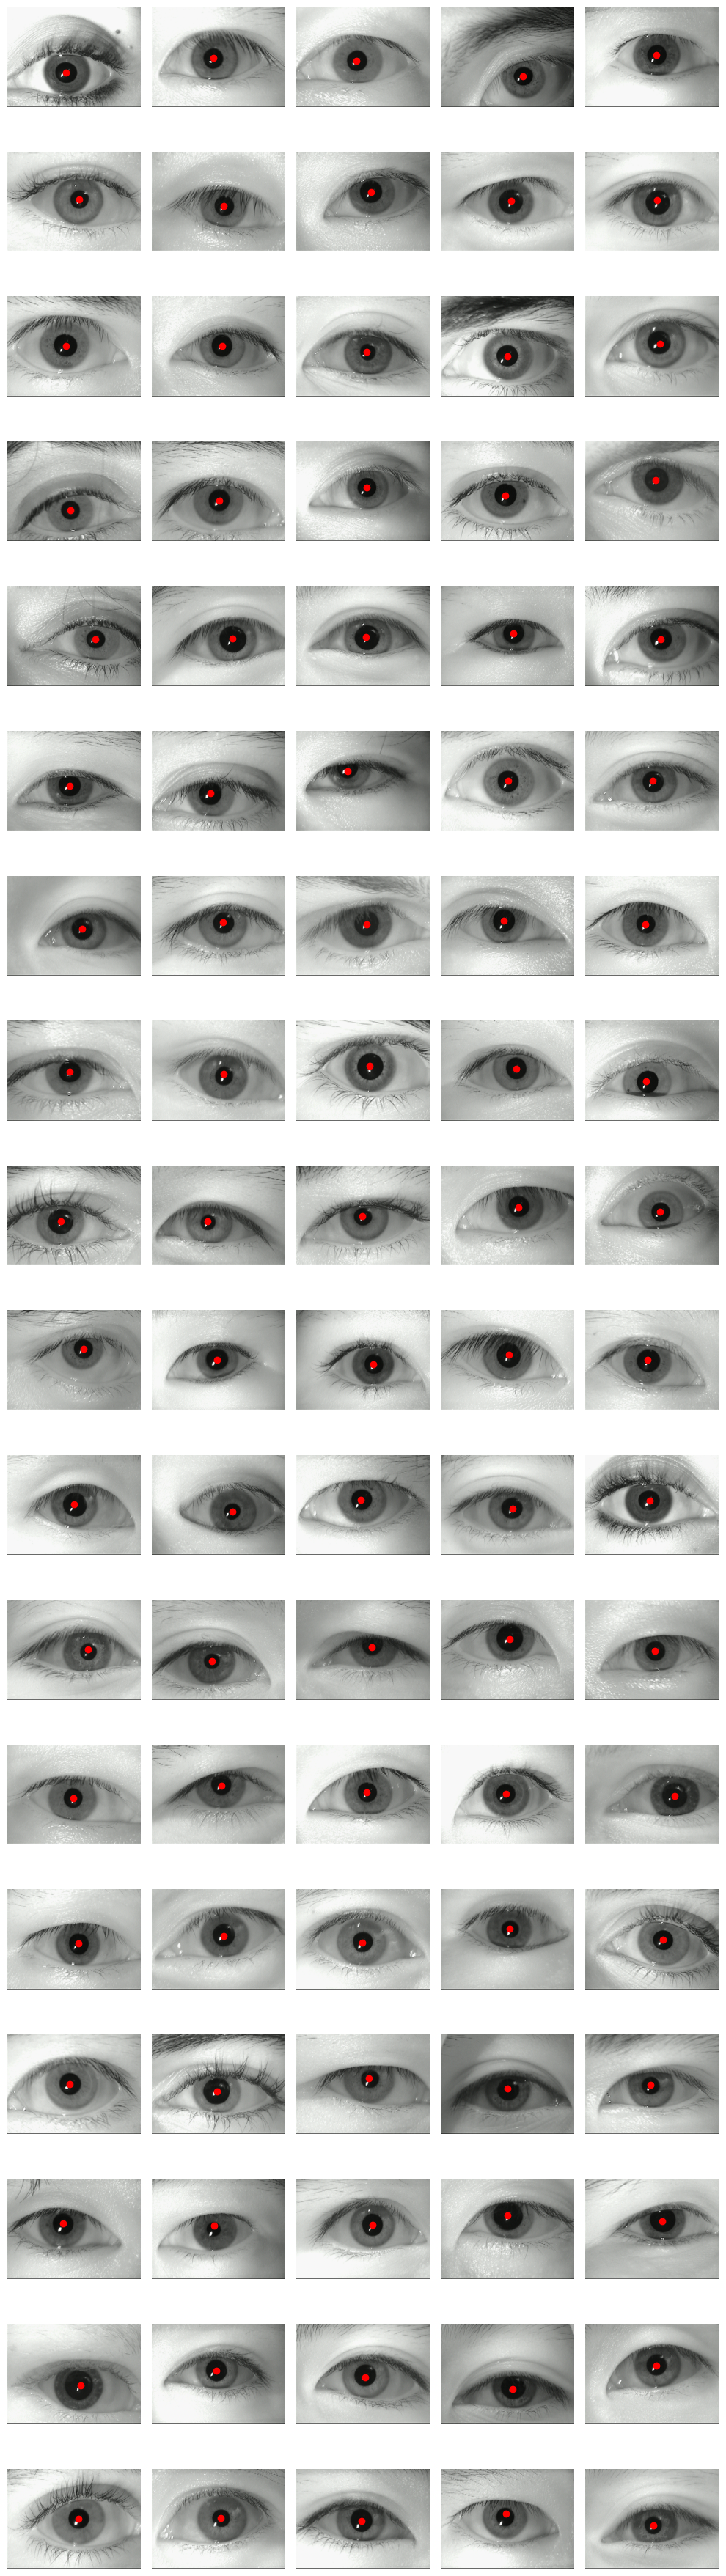

In [41]:
new_pupil_centers = [map_center_to_different_image(center, img_to_transfer_to.shape[:2], base_img.shape[:2]) 
 for center, img_to_transfer_to, base_img
 in zip(pupil_centers, images, cleaned_pupil_images)]

show_images_with_centers(images, new_pupil_centers, num_previews=len(images))

### On other data set

Image 0: final threshold P/X = 6.17 (factor X = 5.05), white ratio = 0.968
Image 1: final threshold P/X = 6.98 (factor X = 4.75), white ratio = 0.973
Image 2: final threshold P/X = 11.67 (factor X = 3.60), white ratio = 0.972
Image 3: final threshold P/X = 3.88 (factor X = 5.70), white ratio = 0.973
Image 4: final threshold P/X = 3.16 (factor X = 5.10), white ratio = 0.967
Image 5: final threshold P/X = 6.15 (factor X = 4.75), white ratio = 0.972
Image 6: final threshold P/X = 4.58 (factor X = 5.25), white ratio = 0.969
Image 7: final threshold P/X = 3.55 (factor X = 5.65), white ratio = 0.970
Image 8: final threshold P/X = 2.84 (factor X = 6.00), white ratio = 0.966
Image 9: final threshold P/X = 5.59 (factor X = 4.85), white ratio = 0.972
Image 10: final threshold P/X = 8.07 (factor X = 4.25), white ratio = 0.974
Image 11: final threshold P/X = 6.58 (factor X = 4.60), white ratio = 0.975
Image 12: final threshold P/X = 6.69 (factor X = 4.20), white ratio = 0.972
Image 13: final thres

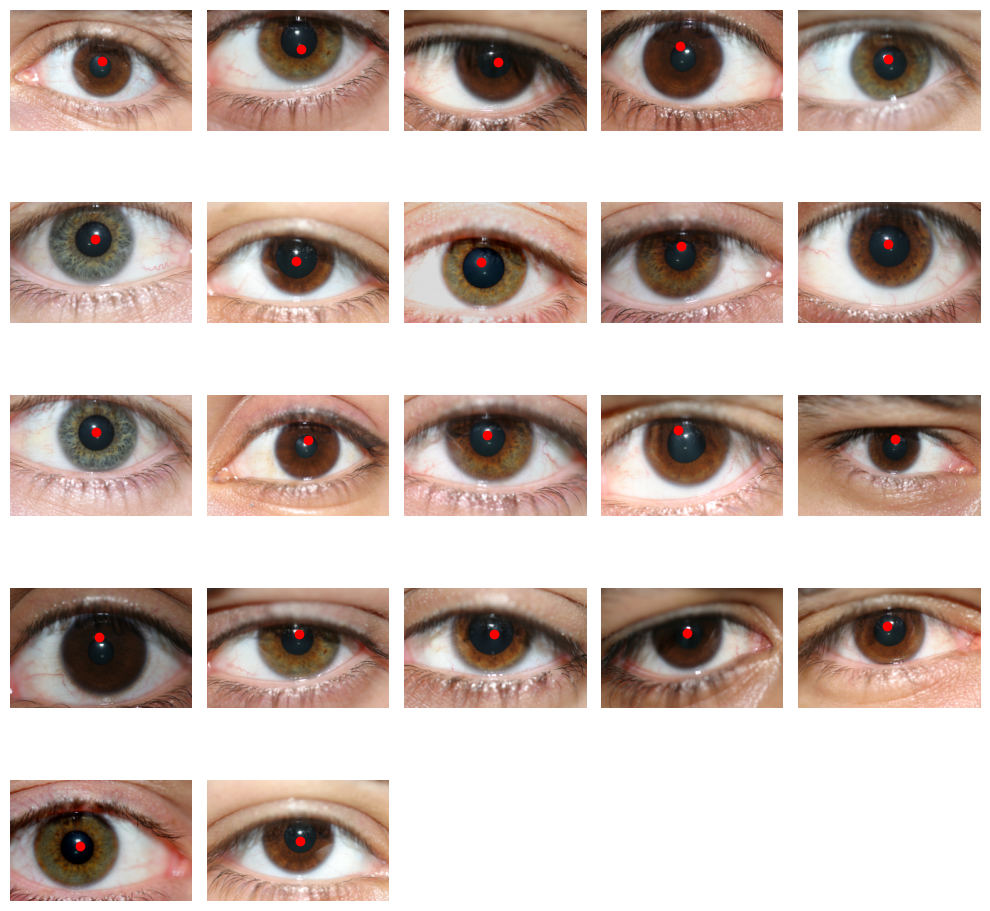

In [42]:
# Loading
images = load_images_ending_with_pattern('teczowka_data', r'.*[^0-9]?1\.[a-zA-Z]+$')

# Resizing
images = resize_images(images, max_size=256)

# Greyscale
grey_images = convert_images_to_greyscale(images)

# Binarization for pupils
binarized_pupil_images = adaptive_binarize_pupil(
        grey_images,
        initial_factor=15,
        white_ratio_thresh=0.975,
        min_factor=1.0,
        factor_step=0.05,
        verbose=False
)

# Closing for pupils
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (20/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
closed_pupil_images = [closing(img, structuring_element, anchor) for img in binarized_pupil_images]

# Opening for pupils
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (10/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
opened_pupil_images = [opening(img, structuring_element, anchor) for img in closed_pupil_images]

# Removing artifacts near border for pupils
cleaned_pupil_images = mask_outside_boundary(opened_pupil_images, x_thresh=0.75, y_thresh=0.75)

# Calculating projections and finding pupil centers
pupil_projections = [compute_projections(img) for img in cleaned_pupil_images]
pupil_centers = get_pupil_centers_from_projections(pupil_projections)

# Showcasing results
new_pupil_centers = [map_center_to_different_image(center, img_to_transfer_to.shape[:2], base_img.shape[:2]) 
 for center, img_to_transfer_to, base_img
 in zip(pupil_centers, images, cleaned_pupil_images)]
show_images_with_centers(images, new_pupil_centers, num_previews=len(images))